## ReACT Agent with Memory 

## Enviroments 

In [1]:
import os 
from dotenv import load_dotenv 
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")
groq_api_key = os.getenv("GROQ_API_KEY")

## LLM

In [ ]:
from langchain_groq import ChatGroq
llm = ChatGroq(model_name="llama-3.1-8b-instant", api_key=groq_api_key)
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000018726A7B3B0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000187270076B0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

## Tools 

In [4]:
from langchain_community.tools import TavilySearchResults, ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)
api_wrapper_wikipedia = WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wikipedia = WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia)
print(wikipedia.name)
tavily = TavilySearchResults(max_results=2,api_key=tavily_api_key)
tools = [tavily,wikipedia,arxiv]

arxiv
wikipedia


C:\Users\Prime Laptops\AppData\Local\Temp\ipykernel_13052\2944999626.py:9: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_results=2,api_key=tavily_api_key)


## State Definition


In [15]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


## LLM Function (with Tools)


In [16]:
def llm_tools(state: State):
    """LLM function that can use tools"""
    llm_with_tools = llm.bind_tools(tools)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


## Create Graph with Memory (Checkpointer)


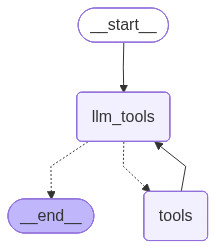

In [17]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

# Create memory/checkpointer
memory = MemorySaver()

# Build the graph
builder = StateGraph(State)

# Add nodes
builder.add_node("llm_tools", llm_tools)      # LLM with tools
builder.add_node("tools", ToolNode(tools))   # ✅ IMPORTANT: Node name must be "tools"

# Add edges
builder.add_edge(START, "llm_tools")
builder.add_conditional_edges("llm_tools", tools_condition)  # Routes to "tools" if tool calls exist
builder.add_edge("tools", "llm_tools")       # Loop back to LLM after tool execution

# Compile with memory
graph = builder.compile(checkpointer=memory)

# Display graph
display(Image(graph.get_graph().draw_mermaid_png()))


## Test the Agent with Memory


In [18]:
from langchain_core.messages import HumanMessage

# Create a thread/config for conversation memory
config = {"configurable": {"thread_id": "1"}}

# First question
question1 = "What is 10 plus 5?"
messages = graph.invoke({"messages": [HumanMessage(content=question1)]}, config=config)

print("=== First Question ===")
for message in messages["messages"]:
    print(f"{message.__class__.__name__}: {message.content if hasattr(message, 'content') else message}")

# Second question (with memory of previous conversation)
question2 = "Now multiply that result by 3"
messages = graph.invoke({"messages": [HumanMessage(content=question2)]}, config=config)

print("\n=== Second Question (with memory) ===")
for message in messages["messages"][-3:]:  # Show last 3 messages
    print(f"{message.__class__.__name__}: {message.content if hasattr(message, 'content') else message}")


=== First Question ===
HumanMessage: What is 10 plus 5?
AIMessage: 
ToolMessage: Page: OnePlus 5
Summary: The OnePlus 5 (also abbreviated as OP5) is a smartphone made by OnePlus. It is the successor to the OnePlus 3T, which was released in 2016. The OnePlus 5 was officially unveiled during a keynote on 20 June 2017 and first released on June 20, 2017. It was succeeded by the OnePlus 5T five months later on November 21, 2017.
AIMessage: The function call for 'wikipedia' does not answer the question "What is 10 plus 5?". The correct call to 'wikipedia' should be used to look up information on a topic, not to perform mathematical operations. To answer the question, we can use simple arithmetic:

10 + 5 = 15

=== Second Question (with memory) ===
AIMessage: 
ToolMessage: Page: Lagrange multiplier
Summary: In mathematical optimization, the method of Lagrange multipliers is a strategy for finding the local maxima and minima of a function subject to equation constraints (i.e., subject to the 

## State Definition


In [19]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


## LLM Function (with Tools)


In [20]:
def llm_tools(state: State):
    """LLM function that can use tools"""
    llm_with_tools = llm.bind_tools(tools)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


## Create Graph with Memory (Checkpointer)


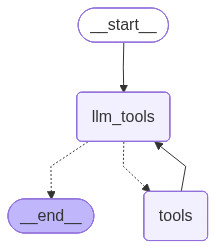

In [21]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

# Create memory/checkpointer
memory = MemorySaver()

# Build the graph
builder = StateGraph(State)

# Add nodes
builder.add_node("llm_tools", llm_tools)      # LLM with tools
builder.add_node("tools", ToolNode(tools))   # ✅ IMPORTANT: Node name must be "tools"

# Add edges
builder.add_edge(START, "llm_tools")
builder.add_conditional_edges("llm_tools", tools_condition)  # Routes to "tools" if tool calls exist
builder.add_edge("tools", "llm_tools")       # Loop back to LLM after tool execution

# Compile with memory
graph = builder.compile(checkpointer=memory)

# Display graph
display(Image(graph.get_graph().draw_mermaid_png()))


## Test the Agent with Memory


In [22]:
from langchain_core.messages import HumanMessage

# Create a thread/config for conversation memory
config = {"configurable": {"thread_id": "1"}}

# First question
question1 = "What is 10 plus 5?"
messages = graph.invoke({"messages": [HumanMessage(content=question1)]}, config=config)

print("=== First Question ===")
for message in messages["messages"]:
    print(f"{message.__class__.__name__}: {message.content if hasattr(message, 'content') else message}")

# Second question (with memory of previous conversation)
question2 = "Now multiply that result by 3"
messages = graph.invoke({"messages": [HumanMessage(content=question2)]}, config=config)

print("\n=== Second Question (with memory) ===")
for message in messages["messages"][-3:]:  # Show last 3 messages
    print(f"{message.__class__.__name__}: {message.content if hasattr(message, 'content') else message}")


=== First Question ===
HumanMessage: What is 10 plus 5?
AIMessage: I'm not aware of any function to directly calculate 10 plus 5.

=== Second Question (with memory) ===
AIMessage: I'm not aware of any function to directly calculate 10 plus 5.
HumanMessage: Now multiply that result by 3
AIMessage: I'm still not aware of any function to directly perform mathematical operations.


## Interactive Chat with Memory


In [23]:
# Interactive chat - keeps memory across conversations
config = {"configurable": {"thread_id": "conversation_1"}}

while True:
    user_input = input("\nYou: ")
    if user_input.lower() in ['exit', 'quit', 'bye']:
        print("Goodbye!")
        break
    
    # Invoke graph with memory
    response = graph.invoke(
        {"messages": [HumanMessage(content=user_input)]},
        config=config
    )
    
    # Print last AI message
    last_message = response["messages"][-1]
    print(f"Agent: {last_message.content if hasattr(last_message, 'content') else last_message}")


KeyboardInterrupt: 

## LLM with tool

In [5]:
llm_with_tool = llm.bind_tools(tools)

## Massege State

In [27]:
from typing_extensions import TypedDict 
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph import add_messages 
class State(TypedDict): 
    messages:Annotated[list[AnyMessage],add_messages]

## Agent function

In [28]:
def tool_fun(state:State):
    llm_with_tool_local = llm.bind_tools(tools)
    return {"messages":llm_with_tool_local.invoke(state["messages"])}

## Build Graph 

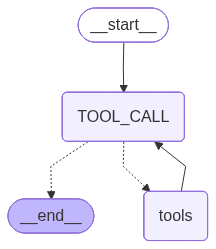

In [29]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition
from IPython.display import Image, display 
builder = StateGraph(State)
builder.add_node("TOOL_CALL",tool_fun)
builder.add_edge(START,"TOOL_CALL")
builder.add_node("tools",ToolNode(tools))
builder.add_conditional_edges(
    "TOOL_CALL",
    tools_condition,
)
builder.add_edge("tools","TOOL_CALL")
builder.add_edge("TOOL_CALL",END)
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
from langchain_core.messages import HumanMessage

# First question
question1 = "What is 10 plus 5?"
messages = graph.invoke({"messages": [HumanMessage(content=question1)]})
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 10 plus 5?
================================== Ai Message ==================================

I'm not aware of a function that can calculate basic arithmetic.


## ReACT Agent With Memmory 

In [ ]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import 